# Domain Triangulation

This notebook demonstrates the application of `Triangulation` class from `/utils/triangulation.py`. Conceptually, the class serve as a generalization of `scipy.Delaunay` triangulation method to include 1D option as well. 

The triangulation is the way most finite element method (FEM) use to linearlize or simplify the PDE solving problem. Unlike the orthogonal gridding commonly used in finite difference method (FDM), the triangulation help us avoid the curse of dimansionality that the number of grid strictly increase exponentially with dimension. This is because triangulation divide the simulation region into simplices that have more freedom in terms of sizes, and orientations. This means that, for example, we can make the simplices very large in the region that we know not much will change during the simulation range, and concentrate more simplices in the interesting region.

To initialize the object, one just need to provided the set of points to the class. These points serve as the simplices' corners. The points can be in any dimensional space as long as the number of (distinct) points are at least one more than the dimension, i.e., to be able to form at least one simplex. The first example, below, show case for a small case in 1D.

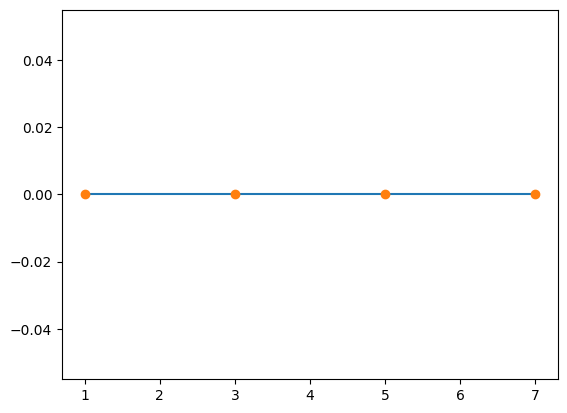

In [15]:
import numpy as np
from utils.triangulation import Triangulation

points_few_1d = np.array([[1], [3], [5], [7]])
triangulation_few_1d = Triangulation(points_few_1d)
triangulation_few_1d.visualize()

We can do similar thing in 2D.

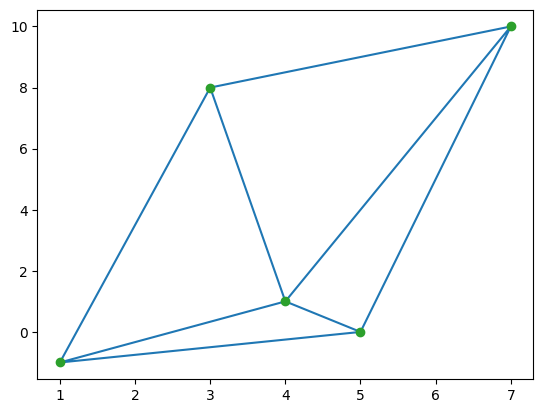

In [16]:
points_few_2d = np.array([[1, -1], [3, 8], [5, 0], [7, 10], [4, 1]])
triangulation_few_2d = Triangulation(points_few_2d)
triangulation_few_2d.visualize()

The higher dimension is also possible, but we don't have a good way to visualize it.

In [17]:
points_few_3d = np.array([[1, -1, 7], [3, 8, 1], [5, 0, 5], [7, 10, 0], [4, 1, 1], [6, 7, 8]])
triangulation_few_3d = Triangulation(points_few_3d)

These three examples are provided with an arbitrary set of points. However, normally, we would know the domain of simulation, and one need to distribute the points properly to gain the best result. Of course, one of the criteria is to have a finer elements in the region of interest. The other criteria is to have enough points on the simulation edge to properly catch the boundary conditions of the problem. The following code show 3 scenarios of triangulation of a unit square in 2D. All interior points use random sampling while the domain edge points are 

1. not exist,

2. only at the domain corners,

3. properly distributed along domain edges.

In [18]:
points_2d_random = np.random.random((20, 2))
points_2d_corner = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
points_2d_edge = np.array([[0, 0.25], [0, 0.50], [0, 0.75], 
                           [0.25, 0], [0.50, 0], [0.75, 0], 
                           [0.25, 1], [0.50, 1], [0.75, 1], 
                           [1, 0.25], [1, 0.50], [1, 0.75]])

points_2d_nothing = points_2d_random
points_2d_noedge = np.concatenate([points_2d_nothing, points_2d_corner], axis = 0)
points_2d_full = np.concatenate([points_2d_noedge, points_2d_edge], axis = 0)

For the one that only contain randomly sampled pointm the triangulation never reach the edge of the simulation region. This means that the elements cannot gain the knowledge of the boundary, e.g., boundary conditions making it not a proper way to triangulate.

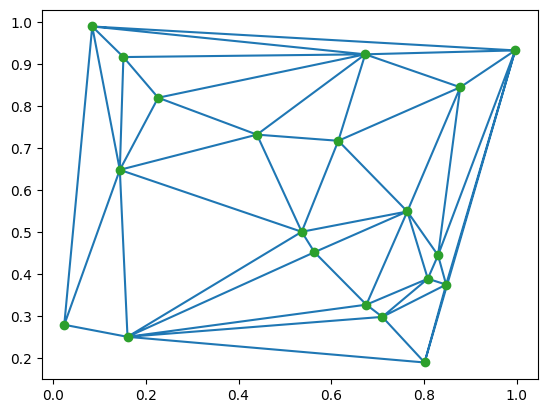

In [19]:
triangulation_2d_nothing = Triangulation(points_2d_nothing)
triangulation_2d_nothing.visualize()

The addition of simulation domain corners help this by including elements that contain has simulation edges as the element edges. However, we can see that such elements are stretched over the whole length of the simulation edges making the triangulation very skewed can might not approximate the PDE well due to the range the elements covered.

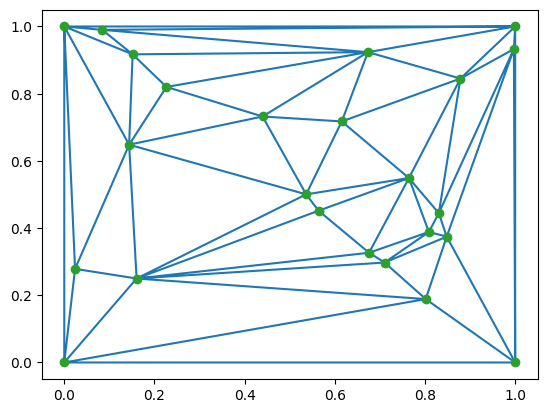

In [20]:
triangulation_2d_noedge = Triangulation(points_2d_noedge)
triangulation_2d_noedge.visualize()

We can improve this by adding more points along the simulation edges to forcefully break down the edge elements into a more localized pieces.

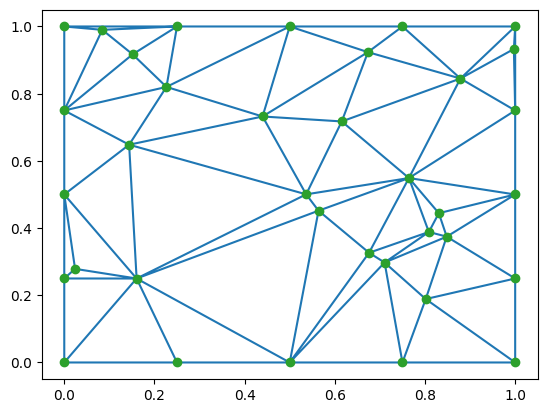

In [21]:
triangulation_2d_full = Triangulation(points_2d_full)
triangulation_2d_full.visualize()

The resulting triangulation object provides many useful functions that we will use through out the process of solving PDE.

## 1. Number of elements and problem dimensions

We can access the number of triangulation simplices and dimension of the problem with attribute `n`, and `d` of the triangulation.

In [22]:
triangulation_2d_full.n, triangulation_2d_full.d

(54, 2)

## 2. Points for triangulation

The attribute `points` give us the points that used for triangulation. Noted that this can be different than the one we use at the object initialization since the code resorts the points and eliminates some potential duplications. Feel free to comment out the `.shape` part to explore the actual tensor.

In [23]:
triangulation_2d_full.points.shape

(36, 2)

## 3. Simplices

The attribute `simplices` give us the array of length `n` each containing `d+1` integer indicating the `points` that form each simplex. The order of the simplices will be used as the indentifying number to locate the elements. The object also contains attribute `neighbors` that tell us all simplices surrounding a particular simplex. The order of those neighbors are such that each one of them are the opposite hyper-plane from the points that form the simplex at the same order. In other words, for 1D, if a simplex (line segment) has left point as order 0 and right point as order 1, then the neighbor of order 0 of this simplex is connected to the right side, i.e., opposite of order 0 point while the neighbor of order 1 is connected to the left side. Hence, this might cause slight irritation for 1D problem, but it is more generalizable to higher dimensional problems.

In [24]:
triangulation_2d_full.simplices.shape

(54, 3)

In [25]:
triangulation_2d_full.neighbors.shape

(54, 3)

## 4. Find simplex

Another important feature of this object is that, given any random point in side the simulation region, it can identify the simplex that contains the point. For example, if we want to check element that contains point $(0.5, 0.5)$ we can use the following code.

In [26]:
p = np.array([[0.5, 0.5]])
p_element = triangulation_2d_full.find_simplex(p)[0]

We can check this by looking at the points that form the particular simplex and check whether the point is inside or not.

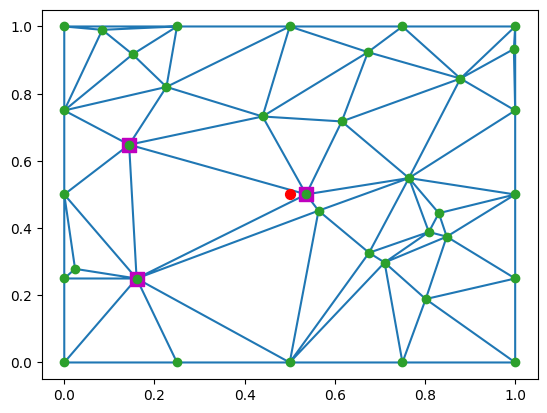

In [27]:
p_simplex = triangulation_2d_full.simplices[p_element]
triangulation_2d_full.visualize(highlight_point = p, highlight_element = p_element)

One can do similar thing for 1D as well.

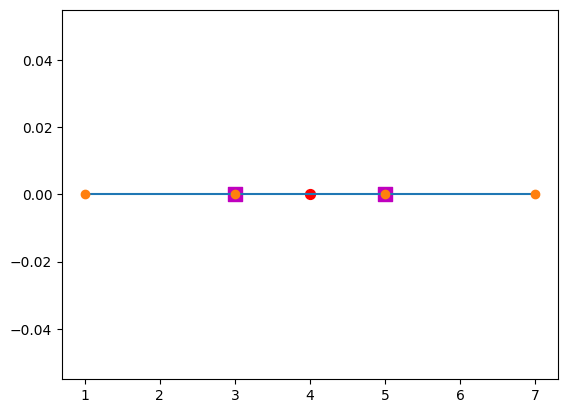

In [28]:
p = np.array([[4]])
p_element = triangulation_few_1d.find_simplex(p)
p_simplex = triangulation_few_1d.simplices[p_element]
triangulation_few_1d.visualize(highlight_point = p, highlight_element = p_element)

Note that the simplex search can be done in a vectorized way, i.e., you can pass an array of points to the functions.

## Final Note

For all simplices at the edge of the simulation, there is no other simplices. Inheriting notations from `scipy`, `-1` is used as the dummy pointer to nothing/environment. However, python indexing use negative indices to point through any iterable from the back. One need to be very careful to handle this dummy pointer not to confused with actual python pointer.